In [1]:
#load required libraries
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

#load data
print("Reading data...")
adata = sc.read_h5ad("../Data/Final.h5ad")
adata

Reading data...


AnnData object with n_obs × n_vars = 92942 × 23249
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'group', 'percent.mt', 'percent.hbb', 'percent.hba', 'nCount_SCT', 'nFeature_SCT', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'total_counts', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts'

normalizing counts per cell
    finished (0:00:09)


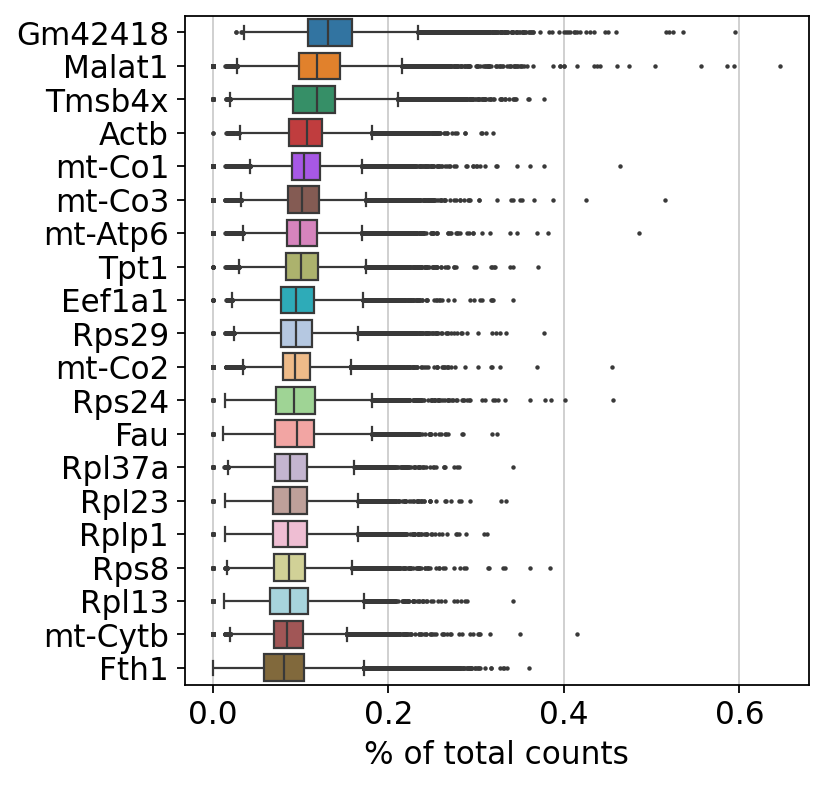

In [2]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [3]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=3000)

# Check which genes are highly variable
print(adata.var['highly_variable'].value_counts())

extracting highly variable genes
    finished (0:00:12)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
highly_variable
False    20249
True      3000
Name: count, dtype: int64


In [4]:
# Run PCA using the highly variable genes
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

computing PCA
    with n_comps=50


/home/gupta385/.local/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:439: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:29)


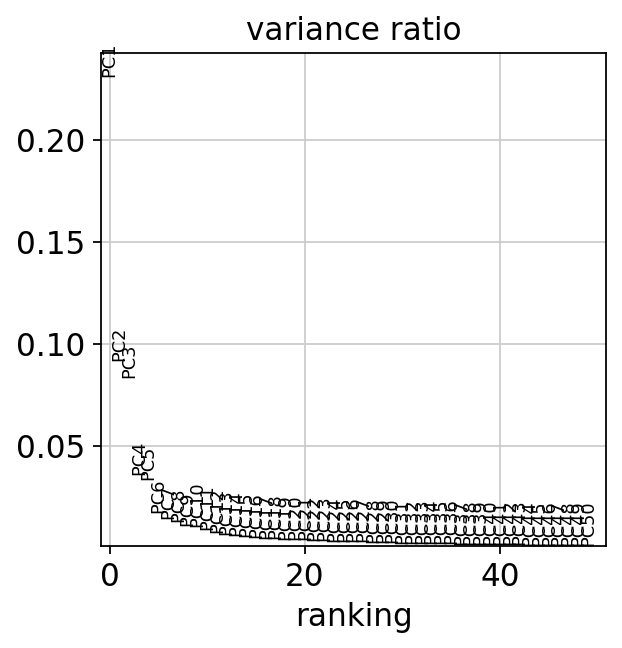

In [5]:
# Plot PCA variance ratio
sc.pl.pca_variance_ratio(adata, n_pcs=50, show=True)

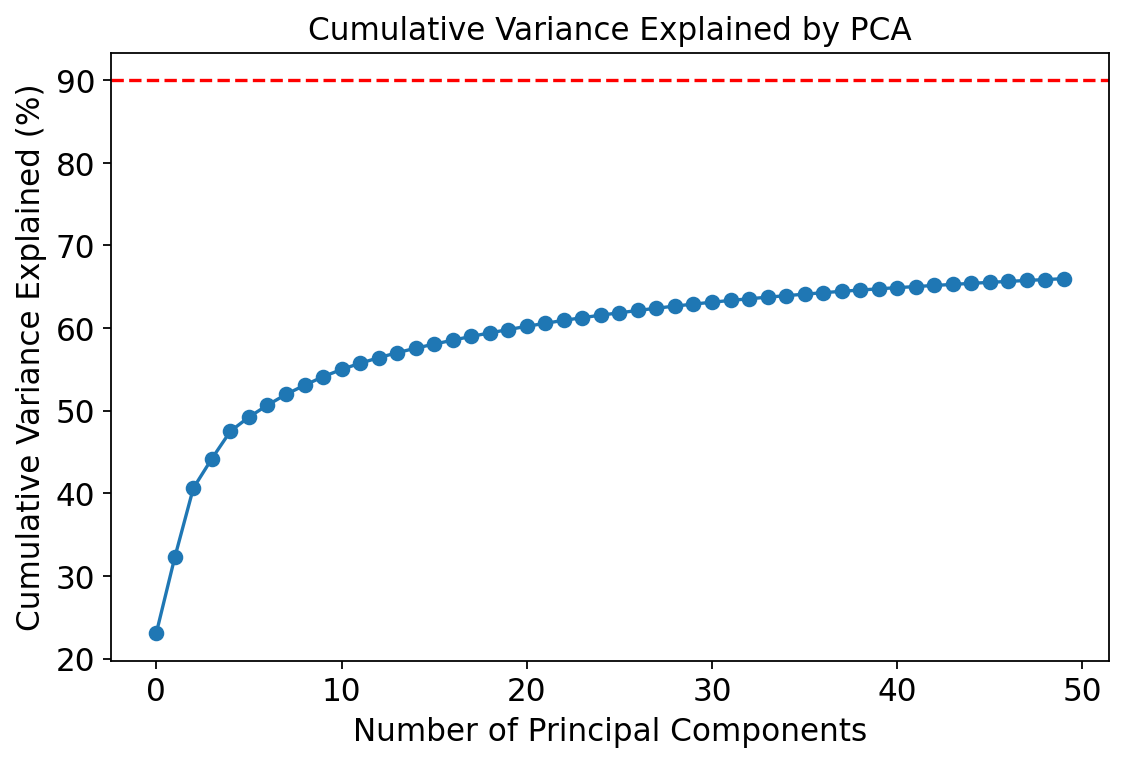

In [6]:
import numpy as np

# Calculate cumulative variance
cumulative_variance = np.cumsum(adata.uns['pca']['variance_ratio']) * 100

# Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.title('Cumulative Variance Explained by PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (%)')
plt.axhline(y=90, color='r', linestyle='--')  # Add a line for 90% variance
plt.grid()
plt.show()

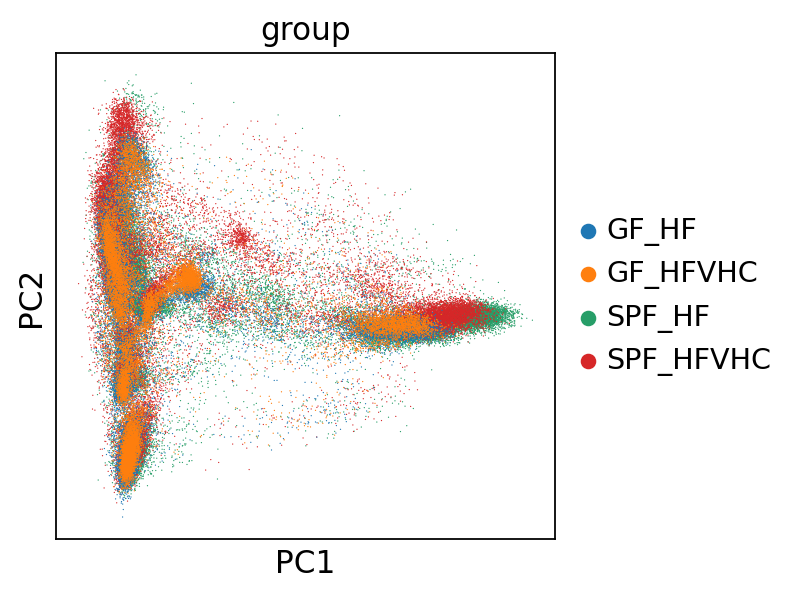

In [7]:
sc.pl.pca(adata, color='group', show=True)

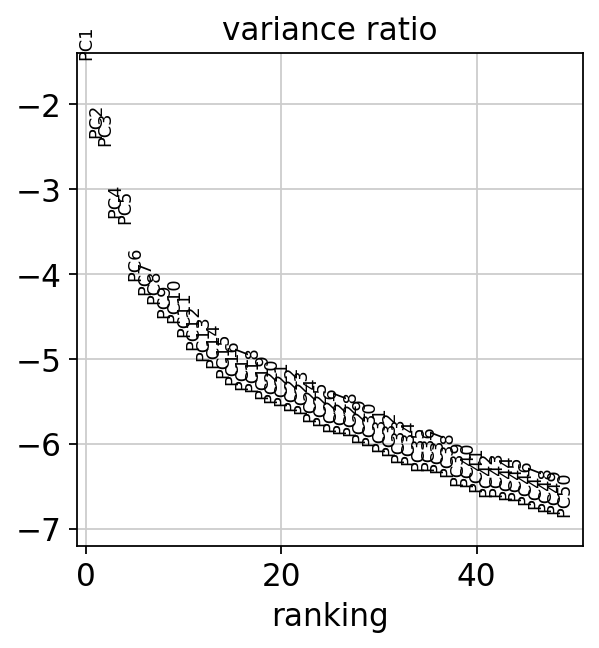

In [8]:
# Elbow plot
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [9]:
# Assuming PCA has been run and variance ratios are available
pca_variance = adata.uns['pca']['variance_ratio']

# Calculate the percentage of variance explained
percent_stdv = pca_variance * 100

# Calculate cumulative variance
cumulative_variance = np.cumsum(percent_stdv)

# Find co1: first PC where cumulative variance exceeds 90% and its variance is less than 5%
co1 = np.where((cumulative_variance > 90) & (percent_stdv < 5))[0]
co1 = co1[0] + 1 if co1.size > 0 else len(percent_stdv)  # If no such PC, use total PCs

# Find co2: first PC where the drop in variance explained is greater than 0.1
drop = np.diff(percent_stdv)  # Calculate the difference between consecutive PCs
co2 = np.where(drop > 0.1)[0]
co2 = co2[0] + 1 if co2.size > 0 else len(percent_stdv)  # If no drop, use total PCs

# Minimum PCs to use
min_pc = min(co1, co2)
print(f'Minimum number of PCs: {min_pc}')

Minimum number of PCs: 50


In [10]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=min_pc)

computing neighbors
    using 'X_pca' with n_pcs = 50


2025-04-04 12:08:03.630507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743786483.668919  576606 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743786483.680633  576606 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743786483.710056  576606 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743786483.710073  576606 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743786483.710077  576606 computation_placer.cc:177] computation placer alr

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:52)


In [ ]:
sc.tl.leiden(adata, resolution=0.2, key_added="leiden_1")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden_2")

running Leiden clustering


/tmp/ipykernel_576606/4124055652.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.2)


    finished: found 20 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:17)


In [ ]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:03:13)


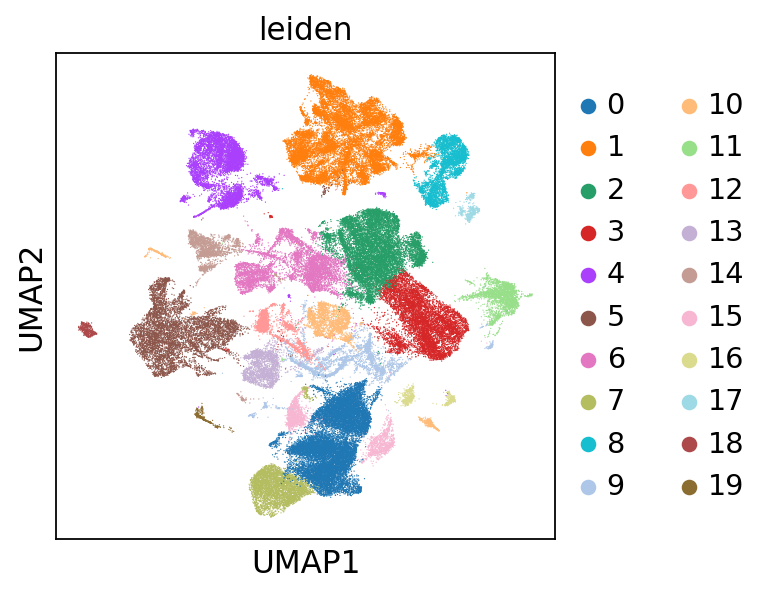

In [ ]:
sc.pl.umap(adata, color='leiden_1', show=True)
sc.pl.umap(adata, color='leiden_2', show=True)

In [ ]:
# Step 1: Run differential expression using Wilcoxon test
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', n_genes=100)

# Step 2: Access results
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names  # e.g., ('0', '1', ..., '18')

# Step 3: Extract and print top 5 genes for each cluster
markers_by_cluster = {}

for group in groups:
    # Create DataFrame for each cluster
    df = pd.DataFrame({
        'gene': result['names'][group],
        'score': result['scores'][group]
    })
    markers_by_cluster[group] = df

    # Print top 5 genes
    print(f"Cluster {group} top 5 genes:")
    for gene in df['gene'][:5]:
        print(f"  - {gene}")
    print("-" * 40)


ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:03)
     gene       score
0   Ptprb  490.518066
1  Adgrf5  453.766785
2    Aqp1  433.605743
3    Nfib  424.353394
4  Igfbp7  415.705353


In [ ]:
immune_cells_cts = [
    "B cells",
    "T cells",
    "NK",
    "Basophils",
    "NK cells",
    "Macrophages",
    "Neutrophils",
    "HSC",
    "Hepatocytes",
    "cDC1",
    "cDC2",
    "pDC",
    "Monocytes",
    "Endothelial cells"
]

In [ ]:
# Gene Markers
immune_cells_cts_liver = {
    "B cells": ["CD19", "CD79A", "MS4A1", "CD22"],
    "T cells": ["CD3D", "CD3E", "TRAC", "CD2", "IL7R"],
    "NK cells": ["NKG7", "KLRD1", "GNLY", "GZMB", "FCGR3A"],
    "Basophils": ["CPA3", "TPSB2", "TPSAB1", "FCER1A", "IL4"],
    "Macrophages": ["CD68", "CD163", "MARCO", "VSIG4", "LYZ", "MRC1"],
    "Monocytes": ["CD14", "LYZ", "S100A8", "S100A9", "FCN1"],
    "Neutrophils": ["S100A8", "S100A9", "MPO", "ELANE", "CSF3R", "FCGR3B"],
    "HSC": ["CD34", "PROM1", "KIT", "THY1", "GATA2"],
    "Hepatocytes": ["ALB", "TTR", "AFP", "CYP3A4", "CYP2E1", "HNF4A", "ASGR1"],
    "cDC1": ["CLEC9A", "XCR1", "BATF3", "IRF8"],
    "cDC2": ["CD1C", "CLEC10A", "FCER1A", "IRF4"],
    "pDC": ["LILRA4", "IL3RA", "TCF4", "GZMB"],
    "Endothelial cells": ["PECAM1", "LYVE1", "STAB1", "CDH5", "VWF", "MRC1"]
}

In [ ]:
marker_genes_in_data = {}
for ct, markers in marker_genes.items():
    markers_found = []
    for marker in markers:
        if marker in adata.var.index:
            markers_found.append(marker)
    marker_genes_in_data[ct] = markers_found

In [ ]:
immune_cells_markers = {
    ct: [m for m in ct_markers if m in adata.var.index]
    for ct, ct_markers in marker_genes.items()
    if ct in immune_cells_cts
}

In [ ]:
sc.pl.dotplot(
    adata,
    groupby="leiden_2",
    var_names=immune_cells_markers,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
)

In [17]:
# Let's say 'T-cells' corresponds to cluster 4
# You can filter the results based on the cluster names
t_cells_markers = adata.uns['rank_genes_groups']['names']['4']  # Replace '4' with the actual cluster number for T-cells
t_cells_scores = adata.uns['rank_genes_groups']['scores']['4']

cluster_17_markers = adata.uns['rank_genes_groups']['names']['17']
cluster_17_scores = adata.uns['rank_genes_groups']['scores']['17']

# Combine names and scores into DataFrames
t_cells_markers_df = pd.DataFrame({
    'gene': t_cells_markers,
    'score': t_cells_scores
})

cluster_17_markers_df = pd.DataFrame({
    'gene': cluster_17_markers,
    'score': cluster_17_scores
})

# Now, we can find the markers that are upregulated in T-cells compared to cluster 17
# You can use a simple merge to find the differences
merged_markers = pd.merge(t_cells_markers_df, cluster_17_markers_df, on='gene', suffixes=('_t_cells', '_cluster_17'))

# Filter based on your criteria
# For example, you can filter based on scores or any other criteria you want
# Here, we will just display the top markers for T-cells that are not in cluster 17
# You can adjust this logic based on your needs

# Display the top 5 markers
print(merged_markers.head(10))

       gene  score_t_cells  score_cluster_17
0     Ikzf3     166.328995         45.238453
1  Arhgap15     161.900940         38.940639
2   Ptprcap     124.706978         50.057354
3       Ltb     124.656158         48.893463
4     Dock2     122.749901         38.676189


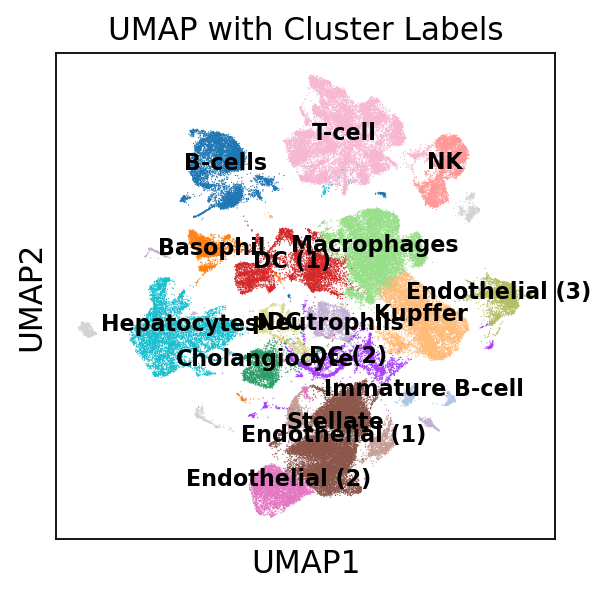

In [20]:
# Assuming you have already clustered your data and have the cluster labels in adata.obs['louvain']
# Define new cluster IDs
new_cluster_ids = {
    '0': 'Endothelial (1)',
    '1': 'T-cell',
    '2': 'Macrophages',
    '3': 'Kupffer',
    '4': 'B-cells',
    '5': 'Hepatocytes',
    '6': 'DC (1)',
    '7': 'Endothelial (2)',
    '8': 'NK',
    '9': 'DC (2)',
    '10': 'Neutrophils',
    '11': 'Endothelial (3)',
    '12': 'pDC',
    '13': 'Cholangiocyte',
    '14': 'Basophil',
    '15': 'Stellate',
    '16': 'Immature B-cell'
}

# Rename clusters in adata.obs
adata.obs['new_cluster_ids'] = adata.obs['leiden'].map(new_cluster_ids)

# Plot UMAP
sc.pl.umap(adata, color='new_cluster_ids', show=False, legend_loc=None)

# Add labels to clusters
plt.title('UMAP with Cluster Labels')
for i, cluster in enumerate(new_cluster_ids.values()):
    plt.text(adata.obsm['X_umap'][adata.obs['new_cluster_ids'] == cluster, 0].mean(),
             adata.obsm['X_umap'][adata.obs['new_cluster_ids'] == cluster, 1].mean(),
             cluster, fontsize=10, fontweight='bold', ha='center')

plt.show()

<Axes: title={'center': 'orig.ident'}, xlabel='UMAP1', ylabel='UMAP2'>

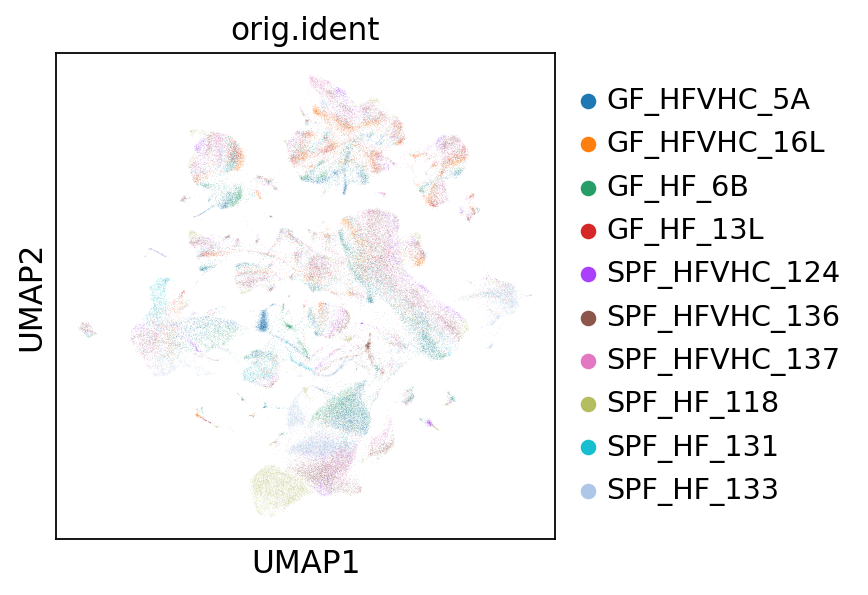

In [22]:
# Plot UMAP for each group, splitting by 'orig.ident'
sc.pl.umap(adata, color='orig.ident', size=0.1, ncols=2, show=False)

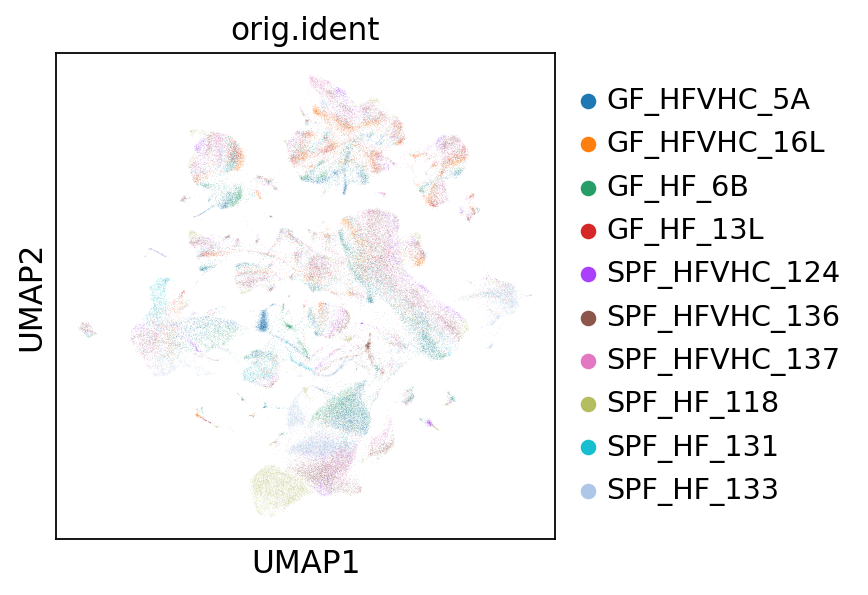

In [23]:
sc.pl.umap(adata, color='orig.ident', size=0.1, show=True)

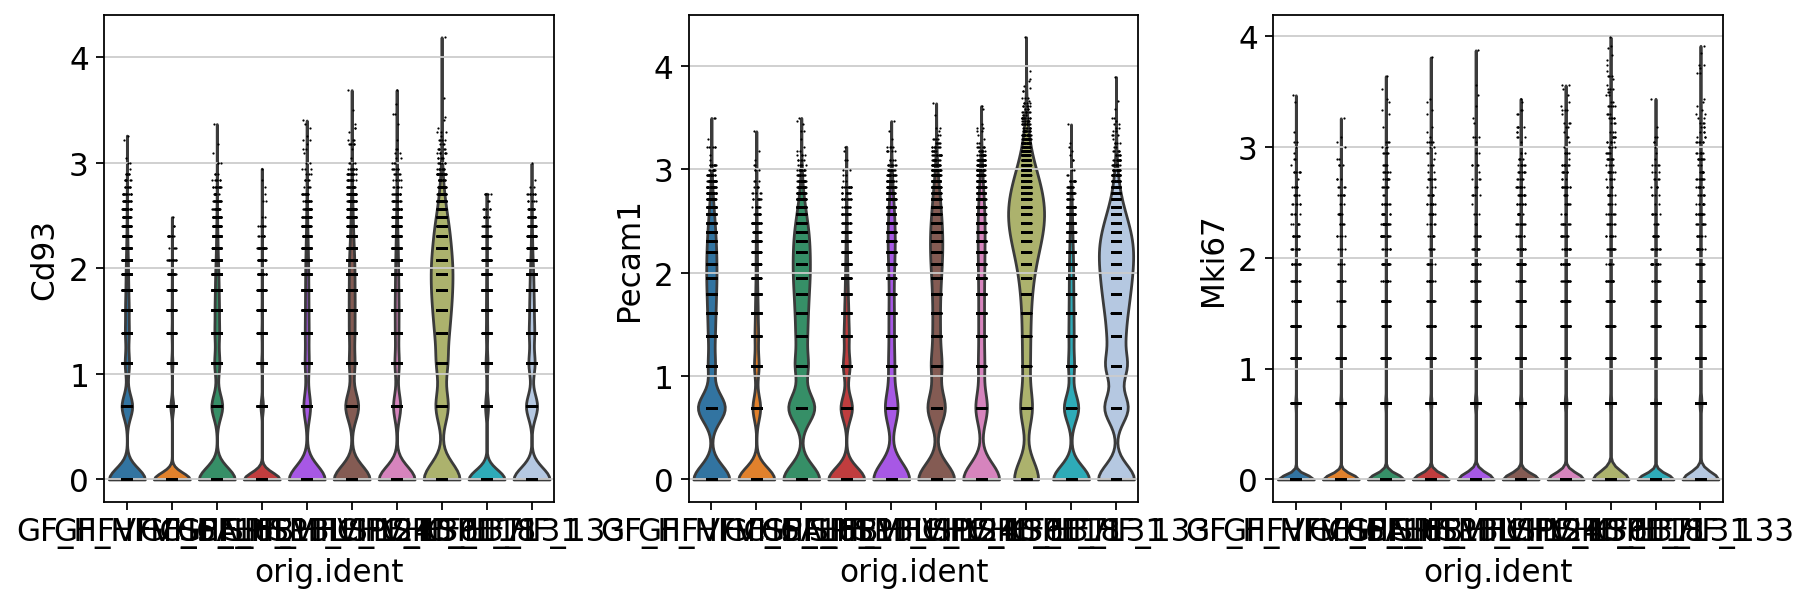

In [24]:
sc.pl.violin(adata, keys=["Cd93", "Pecam1", "Mki67"], groupby='orig.ident', show=True)

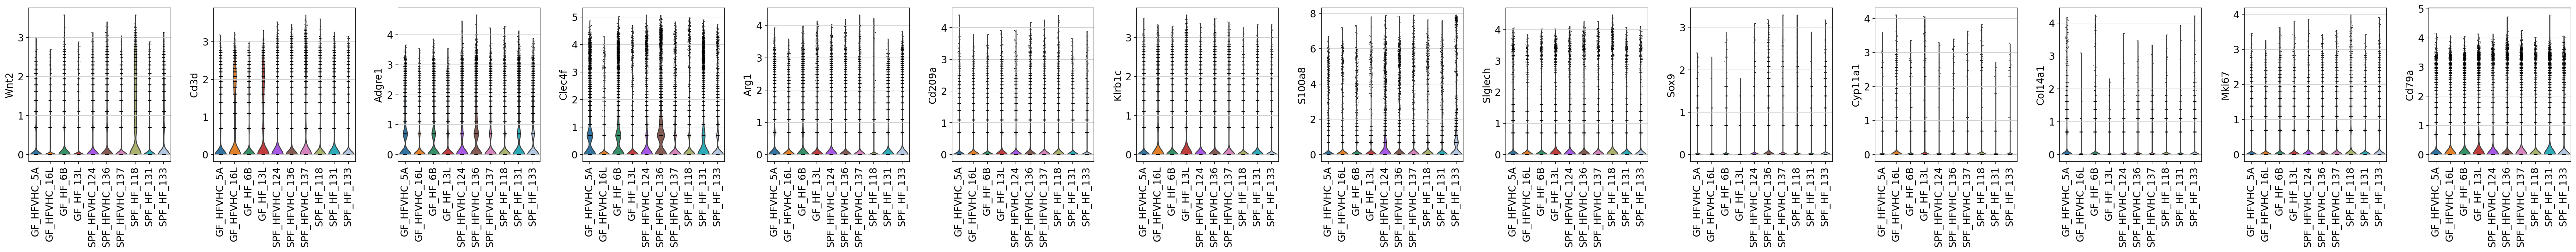

In [25]:
# Stacked violin plot for multiple features
features = ["Wnt2", "Cd3d", "Adgre1", "Clec4f", "Arg1", "Cd209a", "Klrb1c", "S100a8", "Siglech", "Sox9", "Cyp11a1", "Col14a1", "Mki67", "Cd79a"]
sc.pl.violin(adata, keys=features, groupby='orig.ident', rotation=90, show=True)

In [29]:
# Find upregulated genes in SPF HFVHC relative to all other groups
sc.tl.rank_genes_groups(adata, groupby='group', groups=['SPF_HFVHC'], reference='rest', method='t-test')
markers2 = adata.uns['rank_genes_groups']['names']['SPF_HFVHC']
print(markers2)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:13)
['Gm42418' 'Camk1d' 'Cmss1' ... 'Hba-a1' 'Alb' 'Hbb-bs']


In [30]:
# Find upregulated genes in GF_HFVHC relative to all other groups
sc.tl.rank_genes_groups(adata, groupby='group', groups=['GF_HFVHC'], reference='rest', method='t-test')
markers3 = adata.uns['rank_genes_groups']['names']['GF_HFVHC']
print(markers3)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:16)
['Scd1' 'Mup20' 'Apoa2' ... 'Cmss1' 'Cdk8' 'Gm42418']


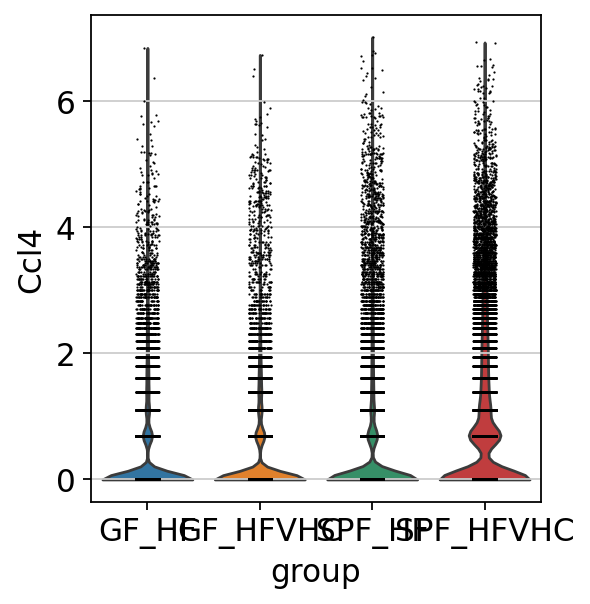

In [31]:
# Violin plot for the "Ccl4" feature, split by 'orig.ident'
sc.pl.violin(adata, keys=["Ccl4"], groupby='group', show=True)

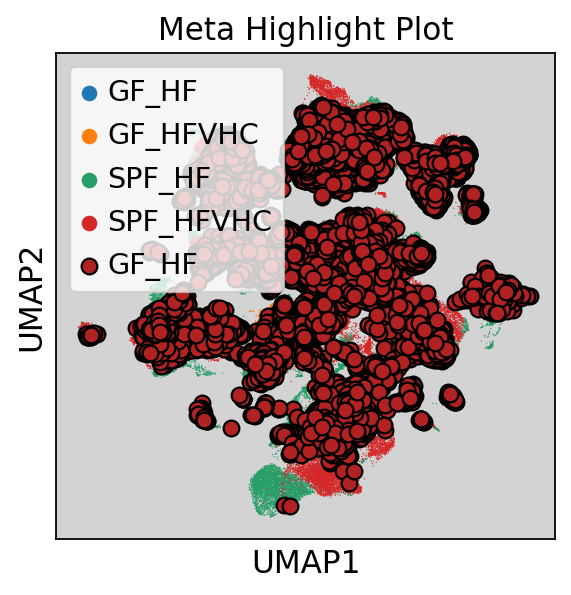

In [32]:
# Assuming 'orig.ident' is in adata.obs and you want to highlight 'GF_HF'
highlight_color = "firebrick"
background_color = "lightgray"

# Create a UMAP plot with highlighted points
sc.pl.umap(adata, color='group', show=False)

# Highlight specific points
highlight_mask = adata.obs['group'] == 'GF_HF'
plt.scatter(adata.obsm['X_umap'][highlight_mask, 0], adata.obsm['X_umap'][highlight_mask, 1],
            color=highlight_color, label='GF_HF', s=50, edgecolor='k')

# Set background color
plt.gca().set_facecolor(background_color)

plt.title('Meta Highlight Plot')
plt.legend()
plt.show()

In [28]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,group,percent.mt,percent.hbb,percent.hba,nCount_SCT,nFeature_SCT,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,new_cluster_ids
0,SPF_HF_118,28874.0,5227,SPF_HF,2.739489,0.000000,0.0,17927.0,4875,4875,5367.287679,37.348251,0.695850,2,Macrophages
1,SPF_HF_118,21951.0,4832,SPF_HF,1.671906,0.009111,0.0,17730.0,4830,4830,5779.449636,34.117682,0.590328,7,Endothelial (2)
2,SPF_HF_118,8036.0,2237,SPF_HF,0.721752,0.000000,0.0,15401.0,2481,2481,3760.179512,25.499117,0.678136,10,Neutrophils
3,SPF_HF_118,24855.0,5247,SPF_HF,1.460471,0.000000,0.0,17616.0,5231,5231,5908.715569,31.206141,0.528137,7,Endothelial (2)
4,SPF_HF_118,21532.0,4990,SPF_HF,3.376370,0.000000,0.0,17783.0,4990,4990,5928.489767,42.250693,0.712672,7,Endothelial (2)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92937,GF_HFVHC_16L,5580.0,2431,GF_HFVHC,2.132616,0.000000,0.0,8358.0,2435,2435,2906.729057,26.250232,0.903085,8,NK
92938,GF_HFVHC_16L,7793.0,2727,GF_HFVHC,2.168613,0.000000,0.0,8588.0,2726,2726,2949.267276,25.210603,0.854809,1,T-cell
92939,GF_HFVHC_16L,1454.0,682,GF_HFVHC,0.343879,0.000000,0.0,7072.0,1969,1969,2251.976624,19.066706,0.846665,5,Hepatocytes
92940,GF_HFVHC_16L,7432.0,2744,GF_HFVHC,2.179763,0.000000,0.0,8501.0,2742,2742,3025.120135,26.993246,0.892303,1,T-cell


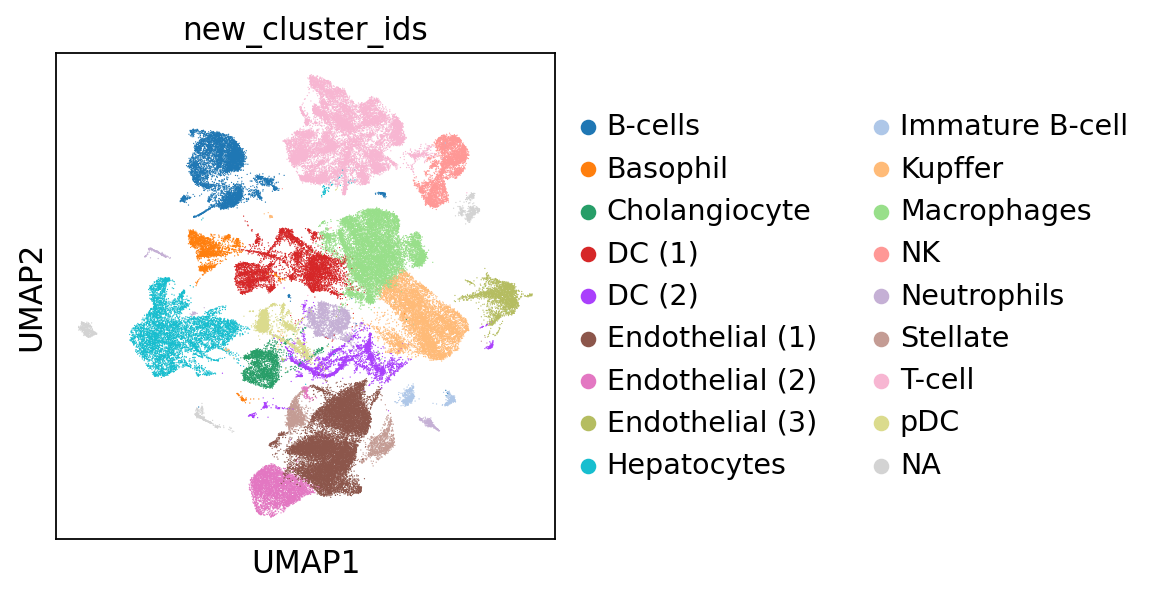

In [33]:
sc.pl.umap(adata, color='new_cluster_ids', show=True)

In [34]:
sc.pl.umap(adata, color='new_cluster_ids', save='umap_plot.png', show=False)

<Axes: title={'center': 'new_cluster_ids'}, xlabel='UMAP1', ylabel='UMAP2'>